### EXPLAIN THIS
1. What is the purpose of a ReLU activation function in CNNs?

--> it introduce the non linearity into the nueral network, and solve the vanishing gradient problem.

--> it is better than sigmoid and tanh.

2. Why is data augmentation useful when training CNN models on medical images?

--> in medical domain there are less amount of patient data, so using data augmentation we can increase the size dataset.

## Q1: Dataset Loading & Splitting (5 marks)

In [1]:
#load dataset
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras

In [ ]:
# train_dataset = "c:/Users/admin/Desktop/8980/DL/Data/train"
# test_dataset = "c:/Users/admin/Desktop/8980/DL/Data/test"

train_data = "c:/Users/admin/Desktop/8980/DL/Data/train"
test_data = "c:/Users/admin/Desktop/8980/DL/Data/test"

train_data = tf.keras.utils.image_dataset_from_directory(
    train_data,
    labels='inferred',
    label_mode='categorical',  
    batch_size=32,
    image_size=(256, 256)
)
test_data = tf.keras.utils.image_dataset_from_directory(
    test_data,
    labels='inferred',
    label_mode='categorical',
    batch_size=32,
    image_size=(256, 256)
)


Found 5144 files belonging to 3 classes.
Found 1288 files belonging to 3 classes.


In [84]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Normalize with rescale=1./255
train_gen = ImageDataGenerator(rescale=1./255)
test_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(
    'c:/Users/admin/Desktop/8980/DL/Data/train', target_size=(256, 256), batch_size=32, class_mode='categorical'
)

test_data = test_gen.flow_from_directory(
    'c:/Users/admin/Desktop/8980/DL/Data/test', target_size=(256, 256), batch_size=32, class_mode='categorical', shuffle=False
)

Found 5144 images belonging to 3 classes.
Found 1288 images belonging to 3 classes.


## Q2. Class Count and Names (2 marks)


In [16]:
num_classes = len(train_data.class_names)
print(f"Number of classes: {num_classes}")
print(f"Class names: {train_data.class_names}")


Number of classes: 3
Class names: ['COVID19', 'NORMAL', 'PNEUMONIA']


## Q3. Data Visualization (5 marks)


In [39]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg 
import random
import os
import glob

In [30]:
class_names = train_data.class_names
print(class_names)

['COVID19', 'NORMAL', 'PNEUMONIA']


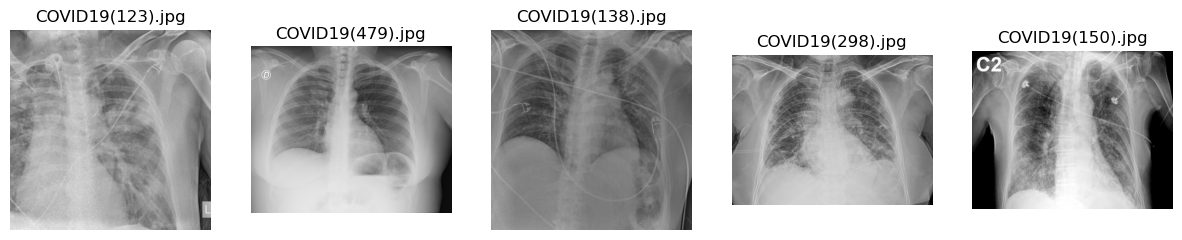

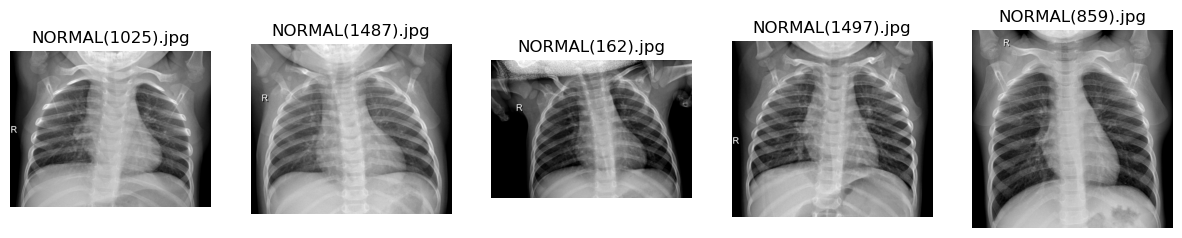

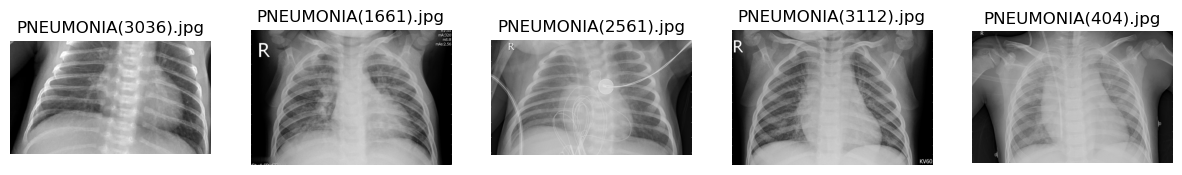

In [ ]:

def show_images_from_class(class_name):
    image_paths = glob.glob(os.path.join(train_dataset, class_name, "*.jpg"))
    selected = random.sample(image_paths, 5)
    
    plt.figure(figsize=(15, 5))
    for i, path in enumerate(selected):
        img = tf.keras.preprocessing.image.load_img(path)
        plt.subplot(1, 5, i + 1)
        plt.imshow(img, cmap='gray')
        plt.title(os.path.basename(path))
        plt.axis('off')
    plt.show()

COVID19 = show_images_from_class(class_name='COVID19')
NORMAL = show_images_from_class(class_name='NORMAL')
PNEUMONIA = show_images_from_class(class_name='PNEUMONIA')

## Q4: Image Grid Preview (8 marks)

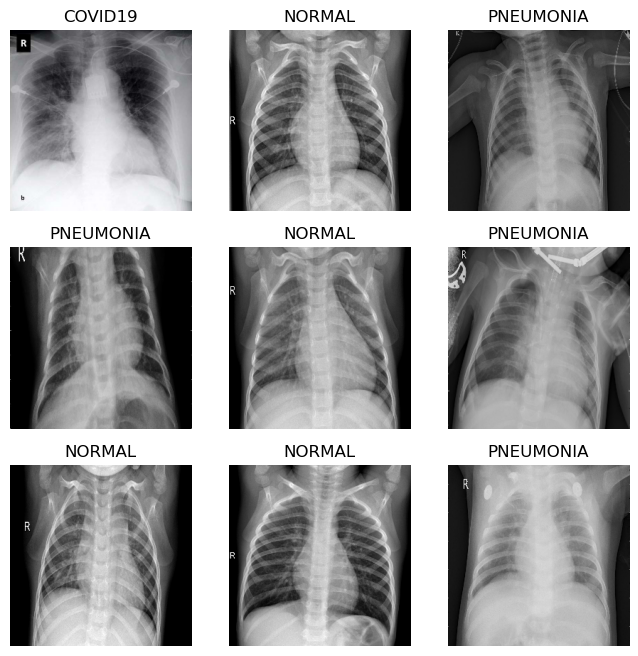

In [65]:
class_name = ['COVID19', 'NORMAL', 'PNEUMONIA']
plt.figure(figsize=(8, 8))
for images, labels in train_data.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_name[tf.argmax(labels[i])])
        plt.axis("off")

## Q5: CNN Architecture (20 marks)

In [41]:
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, BatchNormalization, Flatten, Dense, Dropout

In [42]:
model = Sequential()

#add Convolutional Layer --> 1 with 'relu' and 'MaxPooling
model.add(Conv2D(32, kernel_size=(3,3), padding='same', activation='relu', input_shape=(256, 256, 3)))
model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='same'))

#add Convolutional Layer --> 2 with 'relu' and 'MaxPooling
model.add(Conv2D(32, kernel_size=(3,3), padding='same', activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='same'))

#add Convolutional Layer --> 3 with 'relu' and 'MaxPooling
model.add(Conv2D(128, kernel_size=(3,3), padding='same', activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='same'))

#add Flatten Layer 
model.add(Flatten())

#add Dense Layer 
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(3, activation='softmax'))


c:\Users\admin\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## Q6. Compilation & Summary (5 marks)

In [43]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 256, 256, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 128)    │        36,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 131072)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    16,777,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,824,867 (64.18 MB)

 Trainable params: 16,824,867 (64.18 MB)

 Non-trainable params: 0 (0.00 B)

In [44]:
compile_model = model.compile(optimizer='Adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [71]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 256, 256, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 64, 64, 128)    │        36,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 131072)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │    16,777,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,824,867 (64.18 MB)

 Trainable params: 16,824,867 (64.18 MB)

 Non-trainable params: 0 (0.00 B)

## Q7. Model Training (5 marks)

In [45]:
train_model = model.fit(train_data,
                        validation_data=(test_data),
                        epochs=10,
                        batch_size=128
                        )

Epoch 1/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 104s 629ms/step - accuracy: 0.7238 - loss: 61.1135 - val_accuracy: 0.9356 - val_loss: 0.1954
Epoch 2/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 101s 622ms/step - accuracy: 0.9038 - loss: 0.2780 - val_accuracy: 0.9332 - val_loss: 0.1866
Epoch 3/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 101s 626ms/step - accuracy: 0.9139 - loss: 0.2210 - val_accuracy: 0.9387 - val_loss: 0.1664
Epoch 4/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 99s 613ms/step - accuracy: 0.9302 - loss: 0.1863 - val_accuracy: 0.9464 - val_loss: 0.1484
Epoch 5/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 103s 641ms/step - accuracy: 0.9499 - loss: 0.1414 - val_accuracy: 0.9480 - val_loss: 0.1623
Epoch 6/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 103s 638ms/step - accuracy: 0.9543 - loss: 0.1165 - val_accuracy: 0.9503 - val_loss: 0.1603
Epoch 7/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 105s 651ms/step - accuracy: 0.9536 - loss: 0.1238 - val_accuracy: 0.9542 - val_loss: 0.1337
Epoch 8/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 105s 654ms/step - accuracy: 0.9657 -

## Q8. Performance Graphs (5 marks)

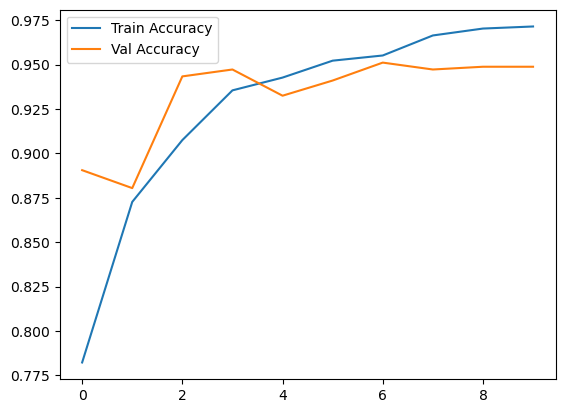

In [73]:
# Accuracy / Loss plots
import matplotlib.pyplot as plt

plt.plot(train_model.history['accuracy'], label='Train Accuracy')
plt.plot(train_model.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.show()

## Q9. Evaluation (5 marks)

In [65]:
#evaluate model on test data
test_loss, test_accuracy = model.evaluate(test_data)
print("Test Accuracy:", test_accuracy)

print(f'Test Loss:{test_loss}')
# print(f'Test Accuracy:{test_accuracy}')
# Predict
y_pred = model.predict(test_data)
y_pred

41/41 ━━━━━━━━━━━━━━━━━━━━ 6s 139ms/step - accuracy: 0.9536 - loss: 0.1368
Test Accuracy: 0.9495341777801514
Test Loss:0.155625581741333
41/41 ━━━━━━━━━━━━━━━━━━━━ 6s 136ms/step


array([[2.9002161e-09, 9.9982738e-01, 1.7259458e-04],
       [7.9760421e-17, 2.6214128e-05, 9.9997377e-01],
       [7.3337751e-12, 6.7279582e-10, 1.0000000e+00],
       ...,
       [8.7161951e-25, 3.9579956e-20, 1.0000000e+00],
       [3.2510838e-17, 1.3790989e-15, 1.0000000e+00],
       [4.6860249e-09, 9.9998581e-01, 1.4212452e-05]], dtype=float32)

## Q10. Confusion Matrix (5 marks)

In [50]:
class_names = train_data.class_names
print(class_names)

['COVID19', 'NORMAL', 'PNEUMONIA']


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 258ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

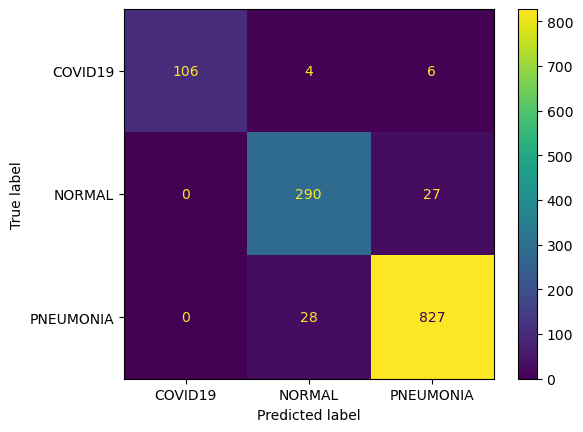

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
y_true = []
y_pred = []
for x_batch, y_batch in test_data:
    y_true.extend(tf.argmax(y_batch, axis=1))
    y_pred.extend(tf.argmax(model.predict(x_batch), axis=1))

cinfusion_m = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cinfusion_m, display_labels=class_names)
disp.plot()
plt.show()

## Q12. Save Trained Model (5 marks)

In [52]:
saved_model = model.save('covid_classifier.h5')
saved_model

## Q11. Prediction (5 marks)

In [82]:
class_names = train_data.class_names
print(class_names)

['COVID19', 'NORMAL', 'PNEUMONIA']


In [58]:
from PIL import Image
import numpy as np
from skimage import transform

def load(filename):
   np_image = Image.open(filename)
   np_image = np.array(np_image).astype('float32')/255
   np_image = transform.resize(np_image, (256, 256, 3))
   np_image = np.expand_dims(np_image, axis=0)
   return np_image

# c:\Users\admin\Desktop\8980\DL\Data\test\NORMAL\NORMAL(156).jpg
image = load('c:/Users/admin/Desktop/8980/DL/Data/test/COVID19/COVID19(216).jpg')
model.predict(image)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step


array([[0.4608301 , 0.12629071, 0.4128792 ]], dtype=float32)